# Principle Components Analysis

## Import the Libraries and Dataset

In [3]:
import pandas as pd
import numpy as np

Use `Digit recognizer` dataset for PCA, It has a `42000` rows and `785` columns

In [4]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(42000, 785)

In [6]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
7860,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Take an example how they data shown so we take a sample value and try to plot this

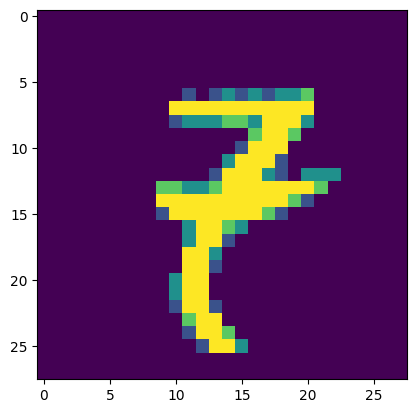

In [7]:
import matplotlib.pyplot as plt

plt.imshow(df.iloc[13042, 1:].values.reshape(28, 28))

## Split the dataset

In [8]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [10]:
X_train.shape

(33600, 784)

## Train the model

In [11]:
from sklearn.neighbors import KNeighborsClassifier

In [12]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [13]:
import time
strt = time.time()

y_pred = knn.predict(X_test)

print(time.time() - strt)

6.9031782150268555


In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9648809523809524

## Perform PCA

In [15]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [16]:
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

In [17]:
# PCA
from sklearn.decomposition import PCA
pca= PCA(n_components=200)

In [18]:
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

After `PCA` we got the transformed data and its shape is now `(33600, 200)` 

In [19]:
X_train_trf.shape

(33600, 200)

In [20]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf, y_train)

KNeighborsClassifier()

In [21]:
y_pred1 = knn.predict(X_test_trf)

In [22]:
accuracy_score(y_test, y_pred1)

0.9507142857142857

We apply a loop so we found the correct and true `no_components` which we need to get higher accuracy in less dimension.

In [23]:
for i in range(1, 785):
    pca = PCA(n_components=i)
    X_train_trf = pca.fit_transform(X_train)
    X_test_trf = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train_trf, y_train)
    y_pred2 = knn.predict(X_test_trf)
    print(f'In N_component {i} : accuracy is {accuracy_score(y_test, y_pred2):.3f}')

In N_component 1 : accuracy is 0.258
In N_component 2 : accuracy is 0.324
In N_component 3 : accuracy is 0.510
In N_component 4 : accuracy is 0.666
In N_component 5 : accuracy is 0.738
In N_component 6 : accuracy is 0.823
In N_component 7 : accuracy is 0.844
In N_component 8 : accuracy is 0.872
In N_component 9 : accuracy is 0.887
In N_component 10 : accuracy is 0.906
In N_component 11 : accuracy is 0.912
In N_component 12 : accuracy is 0.918
In N_component 13 : accuracy is 0.928
In N_component 14 : accuracy is 0.935
In N_component 15 : accuracy is 0.938
In N_component 16 : accuracy is 0.938
In N_component 17 : accuracy is 0.941
In N_component 18 : accuracy is 0.940
In N_component 19 : accuracy is 0.943
In N_component 20 : accuracy is 0.944
In N_component 21 : accuracy is 0.944
In N_component 22 : accuracy is 0.944
In N_component 23 : accuracy is 0.944
In N_component 24 : accuracy is 0.946
In N_component 25 : accuracy is 0.948
In N_component 26 : accuracy is 0.948
In N_component 27 : a

### Transform to a 2D coordinate system

In [25]:
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train_trf)
X_test_trf = pca.transform(X_test_trf)

In [28]:
X_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]])

plot the transformed data

In [29]:
import plotly.express as px
y_train_trf = y_train.astype(str)

fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                color=y_train_trf,
                color_discrete_sequence=px.colors.qualitative.G10
                )
fig.show()

### Transform in 3D

In [30]:
pca=PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [31]:
X_train_trf


array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]])

In [33]:
y_train_trf = y_train.astype(str)

fig = px.scatter_3d(df,
                    x=X_train_trf[:,0],
                    y=X_train_trf[:,1],
                    z=X_train_trf[:,2],
                    color=y_train_trf,
                    color_discrete_sequence=px.colors.qualitative.G10
                )
fig.update_layout(
    margin=dict(l=20,r=20, t=20, b=20)
)
fig.show()

### Some parameters of pca class

In [39]:
pca.explained_variance_
# Its  Eigen Values ......

array([40.67111198, 29.17023401, 26.74459621])

In [38]:
pca.components_.shape
# its Eigen Vector

(3, 784)

In [42]:
pca.explained_variance_ratio_*100

array([5.78519225, 4.14926968, 3.80423901])

### lets find out the opotimal no. of principle components for this datasets

In [43]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.transform(X_test)

In [44]:
pca.explained_variance_.shape

(784,)

In [45]:
pca.components_.shape

(784, 784)

In [48]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

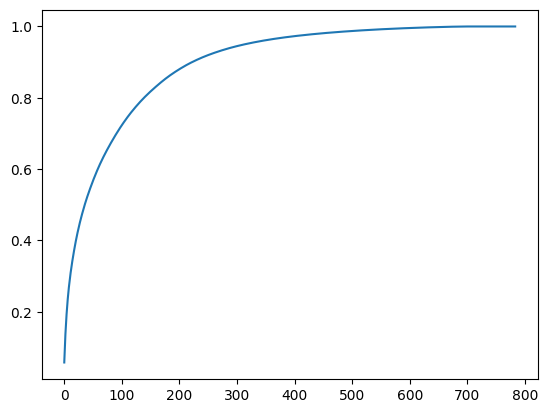

In [49]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))